# Capstone Project: Analisis Buzzer Media Sosial pada Demonstrasi

## Latar Belakang
Media sosial telah menjadi sarana utama untuk berbagi informasi dan menyuarakan pendapat, namun seringkali platform ini disalahgunakan oleh akun-akun buzzer yang sengaja menyebarkan narasi tertentu secara masif dan terkoordinasi. Fenomena ini semakin terlihat jelas saat terjadi peristiwa penting seperti demonstrasi, di mana buzzer berusaha mempengaruhi opini publik.

## Tujuan Proyek
Proyek ini bertujuan untuk:
1. Mengidentifikasi akun-akun buzzer di media sosial terkait isu demonstrasi
2. Menganalisis pola aktivitas dan konten yang mereka sebarkan
3. Memahami dampak buzzer terhadap pembentukan opini publik
4. Mengembangkan metode deteksi otomatis untuk aktivitas buzzer

## Metode Analisis
Kami menggunakan pendekatan multi-metode yang mencakup:
- **Analisis Frekuensi**: Memeriksa pola frekuensi posting dari akun
- **Analisis Kesamaan Konten**: Menggunakan TF-IDF dan cosine similarity untuk mendeteksi konten yang mirip
- **Analisis Sentimen**: Menggunakan model Granite 3.3b untuk mengklasifikasikan sentimen
- **Topic Modeling**: Mengidentifikasi topik-topik utama yang dibahas menggunakan LDA
- **Analisis Temporal**: Menganalisis pola waktu posting untuk mengidentifikasi aktivitas tidak wajar

## Dataset
Data yang digunakan dalam analisis ini berasal dari dua platform media sosial utama:
- **X (Twitter)**: Tweet terkait isu demonstrasi
- **YouTube**: Komentar pada video tentang demonstrasi

## Struktur Notebook
1. **Setup & Konfigurasi**: Instalasi library dan konfigurasi awal
2. **Utility Functions**: Fungsi-fungsi pembantu untuk preprocessing dan analisis
3. **Data Loading**: Memuat dan menggabungkan data dari berbagai sumber
4. **Preprocessing**: Membersihkan dan mempersiapkan data untuk analisis
5. **Buzzer Detection**: Mengidentifikasi akun-akun buzzer potensial
6. **Visualisasi**: Visualisasi hasil analisis buzzer
7. **Analisis Sentimen & Topik**: Menganalisis sentimen dan topik dari konten
8. **Kesimpulan**: Temuan utama dan rekomendasi

In [ ]:
#@title Setup & Konfigurasi

# Impor library yang dibutuhkan
import os
import pandas as pd
import numpy as np
import json
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timezone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud
import warnings

# Konfigurasi
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('fivethirtyeight')
sns.set_context("notebook", font_scale=1.2)

# Direktori data
DATA_DIR = "./data"

# Konfigurasi project
PROJECT_NAME = "Capstone: Buzzer Detection pada Media Sosial"

# API Keys (ganti dengan API key Anda sendiri)
X_BEARER_TOKEN = "YOUR_X_BEARER_TOKEN"  # Ganti dengan token Anda
YOUTUBE_API_KEY = "YOUR_YOUTUBE_API_KEY"  # Ganti dengan API key Anda
REPLICATE_API_KEY = "YOUR_API_KEY_HERE"  # API key untuk Replicate (Granite)

print(f"Setup selesai untuk project: {PROJECT_NAME}")
print(f"Data directory: {DATA_DIR}")

# Cek ketersediaan data
if os.path.exists(DATA_DIR):
    files = os.listdir(DATA_DIR)
    print(f"File yang tersedia di direktori data: {files}")
else:
    print(f"PERINGATAN: Direktori data '{DATA_DIR}' tidak ditemukan!")
    os.makedirs(DATA_DIR, exist_ok=True)
    print(f"Direktori data '{DATA_DIR}' telah dibuat.")

Setup selesai untuk project: Capstone: Buzzer Detection pada Media Sosial
Data directory: ./data
File yang tersedia di direktori data: ['analysis_metadata.json', 'buzzer_analysis_report.html', 'dataset_enriched.csv', 'validation_results.csv', 'x_recent.json', 'yt_comments.json']


## Data Loading dan Preprocessing

Pada bagian ini, kita akan memuat data dari berbagai sumber (X/Twitter dan YouTube) dan melakukan preprocessing dasar seperti pembersihan teks, penghapusan stopwords, dan persiapan untuk analisis selanjutnya.

In [21]:
#@title Data Loading: Memuat Data Tanpa Batasan
import os
import json
import pandas as pd
from datetime import timezone

# Bersihkan data sebelumnya jika ada
if 'data' in globals():
    print(f"Membersihkan data sebelumnya ({len(data)} baris) untuk memuat ulang...")
    del data

print("Memuat SEMUA data dari file JSON tanpa batasan apapun...")
dfs = []

# X (Twitter)
x_path = f"{DATA_DIR}/x_recent.json"
if os.path.exists(x_path):
    try:
        with open(x_path, "r", encoding="utf-8") as f:
            raw = json.load(f)
        tweets = raw.get("data", [])
        print(f"Ditemukan {len(tweets)} tweet di file x_recent.json")
        
        # Muat SEMUA tweet tanpa batasan apapun
        if tweets:
            df = pd.json_normalize(tweets)
            df["source"] = "x"
            df.rename(columns={"text": "content"}, inplace=True, errors="ignore")
            
            # Pilih kolom-kolom yang diperlukan
            x_cols = ["id", "author_id", "created_at", "lang", "content", "source"]
            # Tambahkan kolom public_metrics jika ada
            public_metrics_cols = [col for col in df.columns if col.startswith("public_metrics.")]
            x_cols.extend(public_metrics_cols)
            # Filter kolom yang ada di dataframe
            x_cols_existing = [col for col in x_cols if col in df.columns]
            
            dfs.append(df[x_cols_existing])
            print(f"Berhasil memuat SEMUA {len(df)} tweet dari X tanpa batasan")
    except Exception as e:
        print(f"Error saat memuat data X: {e}")

# YouTube
yt_path = f"{DATA_DIR}/yt_comments.json"
if os.path.exists(yt_path):
    try:
        with open(yt_path, "r", encoding="utf-8") as f:
            raw = json.load(f)
        print(f"Ditemukan {len(raw)} komentar di file yt_comments.json")
        
        # Muat SEMUA komentar YouTube tanpa batasan apapun
        if raw:
            df = pd.DataFrame(raw)
            df["source"] = "youtube"
            df.rename(columns={"publishedAt":"created_at","text":"content"}, inplace=True, errors="ignore")
            dfs.append(df[["author","created_at","likeCount","content","source"]])
            print(f"Berhasil memuat SEMUA {len(df)} komentar dari YouTube tanpa batasan")
    except Exception as e:
        print(f"Error saat memuat data YouTube: {e}")

# Gabungkan data atau buat dummy jika tidak ada
if dfs:
    data = pd.concat(dfs, ignore_index=True)
    print(f"Total data yang berhasil dimuat: {len(data)} baris (tanpa batasan)")
else:
    print("PERINGATAN: Tidak ada file data yang ditemukan! Membuat 5 contoh dummy.")
    data = pd.DataFrame({
        "content":[
            "Tunjangan DPR kebangetan, rakyat makin susah!",
            "Jangan anarkis, protes damai saja.",
            "Saatnya darurat militer biar aman!",
            "Kebijakan ini perlu transparansi, tolong jelaskan.",
            "Hahaha DPR kerja apa sih? sarkas dikit ya."
        ],
        "created_at": pd.date_range("2025-08-20", periods=5, freq="D"),
        "source": ["x","x","youtube","youtube","x"]
    })

# Pastikan created_at adalah datetime dengan timezone
data['created_at'] = pd.to_datetime(data['created_at'], errors='coerce', utc=True)
# Tambahkan kolom date untuk analisis lebih mudah
data["date"] = data["created_at"].dt.date

# Tampilkan info data yang dimuat
print(f"\nInformasi Dataset Final:")
print(f"- Jumlah total data: {len(data)} baris")
print(f"- Distribusi sumber data: {data['source'].value_counts().to_dict()}")
print(f"- Kolom tersedia: {', '.join(data.columns)}")

# Tampilkan contoh data
data.head()

Membersihkan data sebelumnya (200 baris) untuk memuat ulang...
Memuat SEMUA data dari file JSON tanpa batasan apapun...
Ditemukan 100 tweet di file x_recent.json
Berhasil memuat SEMUA 100 tweet dari X tanpa batasan
Ditemukan 100 komentar di file yt_comments.json
Berhasil memuat SEMUA 100 komentar dari YouTube tanpa batasan
Total data yang berhasil dimuat: 200 baris (tanpa batasan)

Informasi Dataset Final:
- Jumlah total data: 200 baris
- Distribusi sumber data: {'x': 100, 'youtube': 100}
- Kolom tersedia: id, author_id, created_at, lang, content, source, public_metrics.retweet_count, public_metrics.reply_count, public_metrics.like_count, public_metrics.quote_count, public_metrics.bookmark_count, public_metrics.impression_count, author, likeCount, date


,id,author_id,created_at,lang,content,source,public_metrics.retweet_count,public_metrics.reply_count,public_metrics.like_count,public_metrics.quote_count,public_metrics.bookmark_count,public_metrics.impression_count,author,likeCount,date
0,1962102543678644523,1118079379022569472,2025-08-31 10:37:55+00:00,in,dpr tu yg diminta bukan maafnya tapi hasil ker...,x,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,2025-08-31
1,1962102542177083861,613436048,2025-08-31 10:37:54+00:00,in,yaallah cing dpr teh aya nu turun ka jalan nem...,x,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,2025-08-31
2,1962102541057220796,1720665183188922368,2025-08-31 10:37:54+00:00,in,@hypersoundNFT @yanzero_ Menurut klaim mantan ...,x,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,2025-08-31
3,1962102539194859707,1890747194019581952,2025-08-31 10:37:54+00:00,in,@SahroniNasdem KONTOL LAGI DI DEMO MALAH KABUR...,x,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,2025-08-31
4,1962102533947797587,450427097,2025-08-31 10:37:52+00:00,in,"DPR Anjing, siluman kontol https://t.co/q8Irly...",x,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,2025-08-31


In [26]:
#@title Inisialisasi Model Granite via Replicate API

import requests
import os
import json
import time

def call_granite_model(prompt, api_key, max_tokens=512):
    """
    Memanggil model Granite via Replicate API
    
    Args:
        prompt (str): Prompt untuk model
        api_key (str): API key Replicate
        max_tokens (int): Jumlah maksimum token untuk output
        
    Returns:
        str: Respon dari model
    """
    # Set API key
    os.environ["REPLICATE_API_TOKEN"] = api_key
    
    # API endpoint
    url = "https://api.replicate.com/v1/predictions"
    
    # Set headers
    headers = {
        "Authorization": f"Token {api_key}",
        "Content-Type": "application/json"
    }
    
    # Set payload dengan nama model yang benar
    data = {
        "version": "ibm-granite/granite-3.3-8b-instruct",  # Nama model yang dikoreksi
        "input": {
            "prompt": prompt,
            "max_length": max_tokens,
            "temperature": 0.1,  # Rendah untuk hasil yang lebih konsisten
            "top_p": 0.9,
            "repetition_penalty": 1.1
        }
    }
    
    # Panggil API
    response = requests.post(url, headers=headers, json=data)
    
    if response.status_code != 201:
        return f"Error: {response.status_code}, {response.text}"
    
    prediction = response.json()
    prediction_id = prediction["id"]
    
    # Cek status prediksi
    url = f"https://api.replicate.com/v1/predictions/{prediction_id}"
    
    while True:
        response = requests.get(url, headers=headers)
        prediction = response.json()
        
        if prediction["status"] == "succeeded":
            return prediction["output"]
        elif prediction["status"] == "failed":
            return f"Error: {prediction['error']}"
            
        time.sleep(1)

# Buat class untuk simulasi interface yang mirip dengan HuggingFace pipeline
class GraniteReplicate:
    def __init__(self, api_key):
        self.api_key = api_key
    
    def generate(self, prompts, max_tokens=512):
        """
        Generate text dari list prompts
        
        Args:
            prompts (list): List prompt untuk model
            max_tokens (int): Jumlah maksimum token untuk output
            
        Returns:
            list: List respon dari model
        """
        if isinstance(prompts, str):
            prompts = [prompts]
            
        results = []
        for prompt in prompts:
            try:
                output = call_granite_model(prompt, self.api_key, max_tokens)
                if isinstance(output, list):
                    output = output[0]  # Ambil hasil pertama
                results.append(output)
            except Exception as e:
                results.append(f"Error: {str(e)}")
                
        return results

# Inisialisasi model
print("Memuat model Granite untuk analisis teks via Replicate API...")
granite_model = GraniteReplicate(api_key=REPLICATE_API_KEY)

# Tes model dengan prompt sederhana
test_result = granite_model.generate("Berikan pendapat singkat tentang media sosial dalam 1 kalimat.")
print("\nHasil tes model Granite:")
print(test_result[0])

print(f"\nModel Granite berhasil dimuat dan siap digunakan via Replicate API!")

Memuat model Granite untuk analisis teks via Replicate API...

Hasil tes model Granite:
Media sosial menawarkan platform yang interaktif untuk berbagi informasi, menghubungi orang, dan mengembangkan komunitas, tetapi juga mungkin menyebabkan isolasi sosial, penyalahgunaan informasi, dan masalah kesehatan mental.

Model Granite berhasil dimuat dan siap digunakan via Replicate API!

Hasil tes model Granite:
Media sosial menawarkan platform yang interaktif untuk berbagi informasi, menghubungi orang, dan mengembangkan komunitas, tetapi juga mungkin menyebabkan isolasi sosial, penyalahgunaan informasi, dan masalah kesehatan mental.

Model Granite berhasil dimuat dan siap digunakan via Replicate API!


In [27]:
#@title Utility Functions: Text Processing & Analysis

# Daftar stopwords bahasa Indonesia
stopwords_id = [
    'ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 
    'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara',
    'antaranya', 'apa', 'apaan', 'apabila', 'apakah', 'apalagi', 'apatah', 'artinya', 'asal',
    'asalkan', 'atas', 'atau', 'ataukah', 'ataupun', 'awal', 'awalnya', 'bagai', 'bagaikan',
    'bagaimana', 'bagaimanakah', 'bagaimanapun', 'bagi', 'bagian', 'bahkan', 'bahwa', 'bahwasanya',
    'baik', 'bakal', 'bakalan', 'balik', 'banyak', 'bapak', 'baru', 'bawah', 'beberapa', 'begini',
    'beginian', 'beginikah', 'beginilah', 'begitu', 'begitukah', 'begitulah', 'begitupun', 'bekerja',
    'belakang', 'belakangan', 'belum', 'belumlah', 'benar', 'benarkah', 'benarlah', 'berada',
    'berakhir', 'berakhirlah', 'berakhirnya', 'berapa', 'berapakah', 'berapalah', 'berapapun',
    'berarti', 'berawal', 'berbagai', 'berdatangan', 'beri', 'berikan', 'berikut', 'berikutnya',
    'berjumlah', 'berkali-kali', 'berkata', 'berkehendak', 'berkeinginan', 'berkenaan', 'berlainan',
    'berlalu', 'berlangsung', 'berlebihan', 'bermacam', 'bermacam-macam', 'bermaksud', 'bermula',
    'bersama', 'bersama-sama', 'bersiap', 'bersiap-siap', 'bertanya', 'bertanya-tanya', 'berturut',
    'berturut-turut', 'bertutur', 'berujar', 'berupa', 'besar', 'betul', 'betulkah', 'biasa',
    'biasanya', 'bila', 'bilakah', 'bisa', 'bisakah', 'boleh', 'bolehkah', 'bolehlah', 'buat',
    'bukan', 'bukankah', 'bukanlah', 'bukannya', 'bulan', 'bung', 'cara', 'caranya', 'cukup',
    'cukupkah', 'cukuplah', 'cuma', 'dahulu', 'dalam', 'dan', 'dapat', 'dari', 'daripada', 'datang',
    'dekat', 'demi', 'demikian', 'demikianlah', 'dengan', 'depan', 'di', 'dia', 'diakhiri', 'diakhirinya',
    'dialah', 'diantara', 'diantaranya', 'diberi', 'diberikan', 'diberikannya', 'dibuat', 'dibuatnya',
    'didapat', 'didatangkan', 'digunakan', 'diibaratkan', 'diibaratkannya', 'diingat', 'diingatkan',
    'diinginkan', 'dijawab', 'dijelaskan', 'dijelaskannya', 'dikarenakan', 'dikatakan', 'dikatakannya',
    'dikerjakan', 'diketahui', 'diketahuinya', 'dikira', 'dilakukan', 'dilalui', 'dilihat', 'dimaksud',
    'dimaksudkan', 'dimaksudkannya', 'dimaksudnya', 'diminta', 'dimintai', 'dimisalkan', 'dimulai',
    'dimulailah', 'dimulainya', 'dimungkinkan', 'dini', 'dipastikan', 'diperbuat', 'diperbuatnya',
    'dipergunakan', 'diperkirakan', 'diperlihatkan', 'diperlukan', 'diperlukannya', 'dipersoalkan',
    'dipertanyakan', 'dipunyai', 'diri', 'dirinya', 'disampaikan', 'disebut', 'disebutkan',
    'disebutkannya', 'disini', 'disinilah', 'ditambahkan', 'ditandaskan', 'ditanya', 'ditanyai',
    'ditanyakan', 'ditegaskan', 'ditujukan', 'ditunjuk', 'ditunjuki', 'ditunjukkan', 'ditunjukkannya',
    'ditunjuknya', 'dituturkan', 'dituturkannya', 'diucapkan', 'diucapkannya', 'diungkapkan',
    'dong', 'dua', 'dulu', 'empat', 'enggak', 'enggaknya', 'entah', 'entahlah', 'guna', 'gunakan',
    'hal', 'hampir', 'hanya', 'hanyalah', 'hari', 'harus', 'haruslah', 'harusnya', 'hendak',
    'hendaklah', 'hendaknya', 'hingga', 'ia', 'ialah', 'ibarat', 'ibaratkan', 'ibaratnya', 'ibu',
    'ikut', 'ingat', 'ingat-ingat', 'ingin', 'inginkah', 'inginkan', 'ini', 'inikah', 'inilah',
    'itu', 'itukah', 'itulah', 'jadi', 'jadilah', 'jadinya', 'jangan', 'jangankan', 'janganlah',
    'jauh', 'jawab', 'jawaban', 'jawabnya', 'jelas', 'jelaskan', 'jelaslah', 'jelasnya', 'jika',
    'jikalau', 'juga', 'jumlah', 'jumlahnya', 'justru', 'kala', 'kalau', 'kalaulah', 'kalaupun',
    'kalian', 'kami', 'kamilah', 'kamu', 'kamulah', 'kan', 'kapan', 'kapankah', 'kapanpun', 'karena',
    'karenanya', 'kasus', 'kata', 'katakan', 'katakanlah', 'katanya', 'ke', 'keadaan', 'kebetulan',
    'kecil', 'kedua', 'keduanya', 'keinginan', 'kelamaan', 'kelihatan', 'kelihatannya', 'kelima',
    'keluar', 'kembali', 'kemudian', 'kemungkinan', 'kemungkinannya', 'kenapa', 'kepada', 'kepadanya',
    'kesamaan', 'keseluruhan', 'keseluruhannya', 'keterlaluan', 'ketika', 'khususnya', 'kini',
    'kinilah', 'kira', 'kira-kira', 'kiranya', 'kita', 'kitalah', 'kok', 'kurang', 'lagi', 'lagian',
    'lah', 'lain', 'lainnya', 'lalu', 'lama', 'lamanya', 'lanjut', 'lanjutnya', 'lebih', 'lewat',
    'lima', 'luar', 'macam', 'maka', 'makanya', 'makin', 'malah', 'malahan', 'mampu', 'mampukah',
    'mana', 'manakala', 'manalagi', 'masa', 'masalah', 'masalahnya', 'masih', 'masihkah', 'masing',
    'masing-masing', 'mau', 'maupun', 'melainkan', 'melakukan', 'melalui', 'melihat', 'melihatnya',
    'memang', 'memastikan', 'memberi', 'memberikan', 'membuat', 'memerlukan', 'memihak', 'meminta',
    'memintakan', 'memisalkan', 'memperbuat', 'mempergunakan', 'memperkirakan', 'memperlihatkan',
    'mempersiapkan', 'mempersoalkan', 'mempertanyakan', 'mempunyai', 'memulai', 'memungkinkan',
    'menaiki', 'menambahkan', 'menandaskan', 'menanti', 'menanti-nanti', 'menantikan', 'menanya',
    'menanyai', 'menanyakan', 'mendapat', 'mendapatkan', 'mendatang', 'mendatangi', 'mendatangkan',
    'menegaskan', 'mengakhiri', 'mengapa', 'mengatakan', 'mengatakannya', 'mengenai', 'mengerjakan',
    'mengetahui', 'menggunakan', 'menghendaki', 'mengibaratkan', 'mengibaratkannya', 'mengingat',
    'mengingatkan', 'menginginkan', 'mengira', 'mengucapkan', 'mengucapkannya', 'mengungkapkan',
    'menjadi', 'menjawab', 'menjelaskan', 'menuju', 'menunjuk', 'menunjuki', 'menunjukkan',
    'menunjuknya', 'menurut', 'menuturkan', 'menyampaikan', 'menyangkut', 'menyatakan', 'menyebutkan',
    'menyeluruh', 'menyiapkan', 'merasa', 'mereka', 'merekalah', 'merupakan', 'meski', 'meskipun',
    'meyakini', 'meyakinkan', 'minta', 'mirip', 'misal', 'misalkan', 'misalnya', 'mula', 'mulai',
    'mulailah', 'mulanya', 'mungkin', 'mungkinkah', 'nah', 'naik', 'namun', 'nanti', 'nantinya',
    'nyaris', 'nyatanya', 'oleh', 'olehnya', 'pada', 'padahal', 'padanya', 'pak', 'paling', 'panjang',
    'pantas', 'para', 'pasti', 'pastilah', 'penting', 'pentingnya', 'per', 'percuma', 'perlu',
    'perlukah', 'perlunya', 'pernah', 'persoalan', 'pertama', 'pertama-tama', 'pertanyaan',
    'pertanyakan', 'pihak', 'pihaknya', 'pukul', 'pula', 'pun', 'punya', 'rasa', 'rasanya', 'rata',
    'rupanya', 'saat', 'saatnya', 'saja', 'sajalah', 'saling', 'sama', 'sama-sama', 'sambil', 'sampai',
    'sampai-sampai', 'sampaikan', 'sana', 'sangat', 'sangatlah', 'satu', 'saya', 'sayalah', 'se',
    'sebab', 'sebabnya', 'sebagai', 'sebagaimana', 'sebagainya', 'sebagian', 'sebaik', 'sebaik-baiknya',
    'sebaiknya', 'sebaliknya', 'sebanyak', 'sebegini', 'sebegitu', 'sebelum', 'sebelumnya', 'sebenarnya',
    'seberapa', 'sebesar', 'sebetulnya', 'sebisanya', 'sebuah', 'sebut', 'sebutlah', 'sebutnya',
    'secara', 'secukupnya', 'sedang', 'sedangkan', 'sedemikian', 'sedikit', 'sedikitnya', 'seenaknya',
    'segala', 'segalanya', 'segera', 'seharusnya', 'sehingga', 'seingat', 'sejak', 'sejauh', 'sejenak',
    'sejumlah', 'sekadar', 'sekadarnya', 'sekali', 'sekali-kali', 'sekalian', 'sekaligus', 'sekalipun',
    'sekarang', 'sekarang', 'sekecil', 'seketika', 'sekiranya', 'sekitar', 'sekitarnya', 'sekurang-kurangnya',
    'sekurangnya', 'sela', 'selain', 'selaku', 'selalu', 'selama', 'selama-lamanya', 'selamanya',
    'selanjutnya', 'seluruh', 'seluruhnya', 'semacam', 'semakin', 'semampu', 'semampunya', 'semasa',
    'semasih', 'semata', 'semata-mata', 'semaunya', 'sementara', 'semisal', 'semisalnya', 'sempat',
    'semua', 'semuanya', 'semula', 'sendiri', 'sendirian', 'sendirinya', 'seolah', 'seolah-olah',
    'seorang', 'sepanjang', 'sepantasnya', 'sepantasnyalah', 'seperlunya', 'seperti', 'sepertinya',
    'sepihak', 'sering', 'seringnya', 'serta', 'serupa', 'sesaat', 'sesama', 'sesampai', 'sesegera',
    'sesekali', 'seseorang', 'sesuatu', 'sesuatunya', 'sesudah', 'sesudahnya', 'setelah', 'setempat',
    'setengah', 'seterusnya', 'setiap', 'setiba', 'setibanya', 'setidak-tidaknya', 'setidaknya',
    'setinggi', 'seusai', 'sewaktu', 'siap', 'siapa', 'siapakah', 'siapapun', 'sini', 'sinilah',
    'soal', 'soalnya', 'suatu', 'sudah', 'sudahkah', 'sudahlah', 'supaya', 'tadi', 'tadinya', 'tahu',
    'tahun', 'tak', 'tambah', 'tambahnya', 'tampak', 'tampaknya', 'tandas', 'tandasnya', 'tanpa',
    'tanya', 'tanyakan', 'tanyanya', 'tapi', 'tegas', 'tegasnya', 'telah', 'tempat', 'tengah',
    'tentang', 'tentu', 'tentulah', 'tentunya', 'tepat', 'terakhir', 'terasa', 'terbanyak',
    'terdahulu', 'terdapat', 'terdiri', 'terhadap', 'terhadapnya', 'teringat', 'teringat-ingat',
    'terjadi', 'terjadilah', 'terjadinya', 'terkira', 'terlalu', 'terlebih', 'terlihat', 'termasuk',
    'ternyata', 'tersampaikan', 'tersebut', 'tersebutlah', 'tertentu', 'tertuju', 'terus',
    'terutama', 'tetap', 'tetapi', 'tiap', 'tiba', 'tiba-tiba', 'tidak', 'tidakkah', 'tidaklah',
    'tiga', 'tinggi', 'toh', 'tunjuk', 'turut', 'tutur', 'tuturnya', 'ucap', 'ucapnya', 'ujar',
    'ujarnya', 'umum', 'umumnya', 'ungkap', 'ungkapnya', 'untuk', 'usah', 'usai', 'waduh', 'wah',
    'wahai', 'waktu', 'waktunya', 'walau', 'walaupun', 'wong', 'yaitu', 'yakin', 'yakni', 'yang'
]

# Kata-kata terkait demonstrasi untuk filtrasi konten
demo_keywords = [
    "demonstrasi", "demo", "protes", "aksi", "turun jalan", "tuntut", "tolak", "massa", "orasi", 
    "orator", "mahasiswa", "aktivis", "dpr", "anggota dewan", "mpr", "parlemen", "unjuk rasa", 
    "ricuh", "bentrok", "aparat", "polisi", "gas air mata", "represif", "kekerasan", "tni", "banteng", 
    "reformasi", "revolusi", "korupsi", "oligarki", "rusuh", "pecah", "uu", "ruu", "undang-undang",
    "aspirasi", "suara rakyat", "tuntutan", "berakhir", "damai", "kericuhan", "ketua", "koordinator",
    "aliansi", "komando", "pesan", "tagar", "viral", "trending", "hastag", "hashtag", "buzzer"
]

def clean_text(text):
    """
    Membersihkan teks dari karakter yang tidak diinginkan
    
    Args:
        text (str): Teks yang akan dibersihkan
        
    Returns:
        str: Teks yang sudah dibersihkan
    """
    if not isinstance(text, str):
        return ""
    
    # Menghapus username
    text = re.sub(r'@\w+', '', text)
    
    # Menghapus URL
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'www\S+', '', text)
    
    # Menghapus hashtag tapi pertahankan teksnya
    text = re.sub(r'#(\w+)', r'\1', text)
    
    # Mengubah ke lowercase
    text = text.lower()
    
    # Menghapus tanda baca
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Menghapus angka
    text = re.sub(r'\d+', '', text)
    
    # Menghapus whitespace berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def remove_stopword(text):
    """
    Menghapus stopwords dari teks
    
    Args:
        text (str): Teks yang akan dihapus stopwordsnya
        
    Returns:
        str: Teks tanpa stopwords
    """
    if not isinstance(text, str):
        return ""
    
    words = text.split()
    filtered_words = [word for word in words if word not in stopwords_id]
    return ' '.join(filtered_words)

def calculate_similarity(text1, text2):
    """
    Menghitung similarity antara dua teks menggunakan cosine similarity
    
    Args:
        text1 (str): Teks pertama
        text2 (str): Teks kedua
        
    Returns:
        float: Nilai similarity (0-1)
    """
    # Vectorize texts
    vectorizer = TfidfVectorizer()
    try:
        tfidf_matrix = vectorizer.fit_transform([text1, text2])
        # Calculate cosine similarity
        similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
        return similarity
    except:
        return 0.0

def get_text_stats(text):
    """
    Mengambil statistik teks seperti jumlah kata, karakter, dll
    
    Args:
        text (str): Teks yang akan dianalisis
        
    Returns:
        dict: Statistik teks
    """
    if not isinstance(text, str) or not text:
        return {
            'char_count': 0,
            'word_count': 0,
            'sentence_count': 0,
            'avg_word_length': 0,
            'avg_sentence_length': 0
        }
    
    # Menghitung jumlah karakter
    char_count = len(text)
    
    # Menghitung jumlah kata
    words = text.split()
    word_count = len(words)
    
    # Menghitung jumlah kalimat (dengan asumsi kalimat diakhiri dengan ., !, atau ?)
    sentences = re.split(r'[.!?]+', text)
    sentence_count = len([s for s in sentences if s.strip()])
    
    # Menghitung rata-rata panjang kata
    avg_word_length = sum(len(word) for word in words) / word_count if word_count > 0 else 0
    
    # Menghitung rata-rata panjang kalimat (dalam kata)
    avg_sentence_length = word_count / sentence_count if sentence_count > 0 else 0
    
    return {
        'char_count': char_count,
        'word_count': word_count,
        'sentence_count': sentence_count,
        'avg_word_length': avg_word_length,
        'avg_sentence_length': avg_sentence_length
    }

def detect_demo_content(text, keywords=demo_keywords, threshold=1):
    """
    Mendeteksi apakah teks terkait dengan demonstrasi
    
    Args:
        text (str): Teks yang akan diperiksa
        keywords (list): Daftar kata kunci terkait demonstrasi
        threshold (int): Jumlah minimum kata kunci yang harus ditemukan
        
    Returns:
        bool: True jika teks terkait demonstrasi, False jika tidak
    """
    if not isinstance(text, str):
        return False
        
    text = text.lower()
    count = sum(1 for keyword in keywords if keyword in text)
    return count >= threshold

# Uji fungsi-fungsi
test_text = "Demo turun jalan di Jakarta. @presiden harus #turunkan harga! https://example.com"
print("Teks asli:", test_text)
print("Setelah dibersihkan:", clean_text(test_text))
print("Tanpa stopwords:", remove_stopword(clean_text(test_text)))
print("Terkait demonstrasi:", detect_demo_content(test_text))
print("Statistik teks:", get_text_stats(test_text))

Teks asli: Demo turun jalan di Jakarta. @presiden harus #turunkan harga! https://example.com
Setelah dibersihkan: demo turun jalan di jakarta harus turunkan harga
Tanpa stopwords: demo turun jalan jakarta turunkan harga
Terkait demonstrasi: True
Statistik teks: {'char_count': 81, 'word_count': 10, 'sentence_count': 4, 'avg_word_length': 7.2, 'avg_sentence_length': 2.5}


## 2) Akuisisi Data (stubs)

In [28]:
#@title Data Preprocessing: Text Cleaning dan Feature Extraction

# Fungsi untuk preprocessing teks dasar (tanpa stopword filtering)
def preprocess_texts(texts, remove_stopwords=False):
    """
    Melakukan preprocessing pada list teks
    
    Args:
        texts (list): List teks yang akan diproses
        remove_stopwords (bool): Apakah menghapus stopwords atau tidak
        
    Returns:
        list: List teks yang sudah diproses
    """
    processed_texts = []
    for text in texts:
        if pd.isna(text):
            processed_texts.append("")
            continue
            
        # Pastikan teks string
        if not isinstance(text, str):
            text = str(text)
            
        # Pembersihan teks menggunakan utility functions
        text = clean_text(text)
        
        # Opsional: Hapus stopwords
        if remove_stopwords:
            text = remove_stopword(text)
            
        processed_texts.append(text)
    
    return processed_texts

# Preprocessing dataset
print("Memulai preprocessing data...")
# Copy data untuk mencegah perubahan pada dataframe asli
processed_data = data.copy()

# Tambahkan kolom untuk teks yang telah diproses
processed_data['clean_text'] = preprocess_texts(processed_data['content'])
processed_data['clean_text_no_stopwords'] = preprocess_texts(processed_data['content'], remove_stopwords=True)

# Vectorisasi teks menggunakan TF-IDF untuk perhitungan kesamaan
print("Melakukan vectorisasi TF-IDF...")
vectorizer = TfidfVectorizer(
    min_df=2,          # Minimal document frequency
    max_df=0.95,       # Maksimal document frequency (untuk menghindari kata-kata yang terlalu umum)
    ngram_range=(1, 2) # Gunakan unigram dan bigram
)

# Fit dan transform data
tfidf_matrix = vectorizer.fit_transform(processed_data['clean_text_no_stopwords'])
print(f"Dimensi matriks TF-IDF: {tfidf_matrix.shape}")

# Tambahkan nilai panjang teks sebagai fitur tambahan
processed_data['text_length'] = processed_data['content'].apply(lambda x: len(str(x)) if not pd.isna(x) else 0)
processed_data['word_count'] = processed_data['clean_text'].apply(lambda x: len(str(x).split()) if not pd.isna(x) else 0)

print("Preprocessing selesai!")
processed_data.head()

Memulai preprocessing data...
Melakukan vectorisasi TF-IDF...
Dimensi matriks TF-IDF: (200, 376)
Preprocessing selesai!


,id,author_id,created_at,lang,content,source,public_metrics.retweet_count,public_metrics.reply_count,public_metrics.like_count,public_metrics.quote_count,public_metrics.bookmark_count,public_metrics.impression_count,author,likeCount,date,clean_text,clean_text_no_stopwords,text_length,word_count
0,1962102543678644523,1118079379022569472,2025-08-31 10:37:55+00:00,in,dpr tu yg diminta bukan maafnya tapi hasil ker...,x,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,2025-08-31,dpr tu yg diminta bukan maafnya tapi hasil ker...,dpr tu yg maafnya hasil kerjanya kalo maaf mah...,112,17
1,1962102542177083861,613436048,2025-08-31 10:37:54+00:00,in,yaallah cing dpr teh aya nu turun ka jalan nem...,x,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,2025-08-31,yaallah cing dpr teh aya nu turun ka jalan nem...,yaallah cing dpr teh aya nu turun ka jalan nem...,138,24
2,1962102541057220796,1720665183188922368,2025-08-31 10:37:54+00:00,in,@hypersoundNFT @yanzero_ Menurut klaim mantan ...,x,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,2025-08-31,menurut klaim mantan kepala bin am hendropriyo...,klaim mantan kepala bin am hendropriyono aktor...,301,39
3,1962102539194859707,1890747194019581952,2025-08-31 10:37:54+00:00,in,@SahroniNasdem KONTOL LAGI DI DEMO MALAH KABUR...,x,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,2025-08-31,kontol lagi di demo malah kabur ke luar negri ...,kontol demo kabur negri ya anjjng gausah indo ...,112,18
4,1962102533947797587,450427097,2025-08-31 10:37:52+00:00,in,"DPR Anjing, siluman kontol https://t.co/q8Irly...",x,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,2025-08-31,dpr anjing siluman kontol,dpr anjing siluman kontol,50,4


In [30]:
#@title Buzzer Detection: Identifikasi Akun Buzzer

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def compute_similarity_matrix(tfidf_matrix):
    """
    Menghitung matriks kesamaan cosine dari matriks TF-IDF
    
    Args:
        tfidf_matrix: Matriks TF-IDF dari teks yang telah diproses
        
    Returns:
        Matriks kesamaan cosine
    """
    return cosine_similarity(tfidf_matrix)

def identify_similar_content_groups(similarity_matrix, threshold=0.7):
    """
    Mengidentifikasi kelompok konten yang mirip berdasarkan matriks kesamaan
    
    Args:
        similarity_matrix: Matriks kesamaan cosine
        threshold: Ambang batas kesamaan untuk mengelompokkan konten
        
    Returns:
        List kelompok indeks yang kontennya mirip
    """
    similar_groups = []
    n = similarity_matrix.shape[0]
    visited = set()
    
    for i in range(n):
        if i in visited:
            continue
            
        # Dapatkan indeks konten yang mirip dengan konten saat ini
        similar_indices = set(np.where(similarity_matrix[i] > threshold)[0])
        # Hapus diri sendiri dari kelompok
        if i in similar_indices:
            similar_indices.remove(i)
            
        # Jika ada konten yang mirip, buat kelompok baru
        if similar_indices:
            group = {i} | similar_indices
            similar_groups.append(list(group))
            visited.update(group)
    
    return similar_groups

def compute_buzzer_score(data, similarity_matrix, threshold=0.7):
    """
    Menghitung skor buzzer untuk setiap akun berdasarkan faktor-faktor berikut:
    1. Frekuensi posting
    2. Kesamaan konten (dengan pengguna lain dan diri sendiri)
    3. Pola waktu posting
    
    Args:
        data: DataFrame yang berisi data
        similarity_matrix: Matriks kesamaan cosine
        threshold: Ambang batas kesamaan untuk mengelompokkan konten
        
    Returns:
        DataFrame dengan skor buzzer untuk setiap akun
    """
    # Identifikasi kelompok konten yang mirip
    similar_groups = identify_similar_content_groups(similarity_matrix, threshold)
    
    # Identifikasi penulis unik
    author_field = 'author_id' if 'author_id' in data.columns else 'author'
    
    # Periksa apakah kolom author ada dalam data
    if author_field not in data.columns:
        print(f"Peringatan: Kolom '{author_field}' tidak ditemukan dalam data!")
        print(f"Kolom yang tersedia: {data.columns.tolist()}")
        return pd.DataFrame()  # Return empty DataFrame jika kolom tidak ada
    
    # Mendapatkan authors yang valid
    authors = data[author_field].dropna().unique()
    if len(authors) == 0:
        print(f"Peringatan: Tidak ada nilai author yang valid dalam kolom '{author_field}'!")
        return pd.DataFrame()  # Return empty DataFrame jika tidak ada author valid
    
    # DataFrame untuk menyimpan skor buzzer
    buzzer_scores = pd.DataFrame({
        'author': authors,
        'post_count': 0,
        'similar_content_count': 0,
        'unique_content_ratio': 0,
        'posting_frequency': 0,
        'buzzer_score': 0
    })
    
    # Hitung jumlah posting untuk setiap penulis
    author_post_counts = data[author_field].value_counts().to_dict()
    buzzer_scores['post_count'] = buzzer_scores['author'].map(author_post_counts)
    
    # Hitung jumlah konten yang mirip untuk setiap penulis
    for author in authors:
        author_indices = data[data[author_field] == author].index.tolist()
        similar_content_count = 0
        
        for group in similar_groups:
            # Jika penulis memiliki konten dalam kelompok yang sama, tambahkan ke hitungan
            author_in_group = sum(1 for idx in group if idx in author_indices)
            if author_in_group > 0:
                similar_content_count += author_in_group
        
        # Perbarui skor untuk penulis ini
        author_rows = buzzer_scores[buzzer_scores['author'] == author]
        if not author_rows.empty:
            idx = author_rows.index[0]
            buzzer_scores.at[idx, 'similar_content_count'] = similar_content_count
        else:
            print(f"Peringatan: Author '{author}' tidak ditemukan dalam buzzer_scores!")
    
    # Hitung rasio konten unik
    buzzer_scores['unique_content_ratio'] = 1 - (buzzer_scores['similar_content_count'] / buzzer_scores['post_count'])
    buzzer_scores['unique_content_ratio'] = buzzer_scores['unique_content_ratio'].fillna(1)
    
    # Hitung frekuensi posting (jika ada informasi waktu)
    if 'created_at' in data.columns:
        for author in authors:
            author_posts = data[data[author_field] == author]
            if len(author_posts) > 1:
                # Periksa tipe data kolom created_at
                if pd.api.types.is_datetime64_any_dtype(author_posts['created_at']):
                    # Urutkan posting berdasarkan waktu
                    sorted_posts = author_posts.sort_values('created_at')
                    # Hitung interval waktu antar posting dalam detik
                    time_diffs = sorted_posts['created_at'].diff().dt.total_seconds()
                    # Hitung rata-rata interval waktu (dalam jam)
                    avg_interval = time_diffs.mean() / 3600 if not time_diffs.empty else 24
                    # Semakin kecil interval, semakin tinggi frekuensi posting
                    posting_frequency = 24 / avg_interval if avg_interval > 0 else 1
                    
                    # Perbarui skor untuk penulis ini
                    author_rows = buzzer_scores[buzzer_scores['author'] == author]
                    if not author_rows.empty:
                        idx = author_rows.index[0]
                        buzzer_scores.at[idx, 'posting_frequency'] = posting_frequency
                else:
                    print(f"Peringatan: Kolom 'created_at' bukan tipe datetime. Tipe saat ini: {type(author_posts['created_at'].iloc[0])}")
    
    # Normalisasi skor
    for col in ['post_count', 'similar_content_count', 'posting_frequency']:
        max_val = buzzer_scores[col].max()
        if max_val > 0:
            buzzer_scores[col] = buzzer_scores[col] / max_val
    
    # Hitung skor buzzer akhir (dengan pembobotan)
    buzzer_scores['buzzer_score'] = (
        0.3 * buzzer_scores['post_count'] + 
        0.4 * (1 - buzzer_scores['unique_content_ratio']) + 
        0.3 * buzzer_scores['posting_frequency']
    )
    
    # Urutkan berdasarkan skor buzzer (dari tinggi ke rendah)
    buzzer_scores = buzzer_scores.sort_values('buzzer_score', ascending=False).reset_index(drop=True)
    
    return buzzer_scores

# Hitung matriks kesamaan
print("Menghitung matriks kesamaan konten...")
similarity_matrix = compute_similarity_matrix(tfidf_matrix)
print(f"Dimensi matriks kesamaan: {similarity_matrix.shape}")

# Tambahkan pengecekan data sebelum menganalisis
print("\nCek data sebelum analisis buzzer:")
print(f"Jumlah baris data: {len(processed_data)}")
print(f"Kolom dalam data: {processed_data.columns.tolist()}")

# Tambahkan kolom author jika tidak ada
if 'author' not in processed_data.columns and 'author_id' not in processed_data.columns:
    print("Menambahkan kolom author dummy untuk demo...")
    processed_data['author'] = processed_data.index.map(lambda x: f"user_{x}")

# Hitung skor buzzer
print("\nMengidentifikasi akun buzzer potensial...")
buzzer_scores = compute_buzzer_score(processed_data, similarity_matrix, threshold=0.7)

# Periksa apakah hasil kosong
if buzzer_scores.empty:
    print("Tidak dapat menghitung skor buzzer. Periksa pesan error di atas.")
else:
    # Tetapkan kategori untuk setiap penulis
    buzzer_scores['category'] = pd.cut(
        buzzer_scores['buzzer_score'],
        bins=[-0.1, 0.3, 0.6, 1.0],
        labels=['Normal', 'Potential Buzzer', 'Likely Buzzer']
    )

    # Tampilkan hasil
    print(f"\nHasil Deteksi Buzzer:")
    print(f"- Total akun yang dianalisis: {len(buzzer_scores)}")
    print(f"- Akun normal: {len(buzzer_scores[buzzer_scores['category'] == 'Normal'])}")
    print(f"- Potential buzzer: {len(buzzer_scores[buzzer_scores['category'] == 'Potential Buzzer'])}")
    print(f"- Likely buzzer: {len(buzzer_scores[buzzer_scores['category'] == 'Likely Buzzer'])}")

    # Tampilkan top buzzer
    print("\nTop 10 akun dengan skor buzzer tertinggi:")
    display(buzzer_scores.head(10))

Menghitung matriks kesamaan konten...
Dimensi matriks kesamaan: (200, 200)

Cek data sebelum analisis buzzer:
Jumlah baris data: 200
Kolom dalam data: ['id', 'author_id', 'created_at', 'lang', 'content', 'source', 'public_metrics.retweet_count', 'public_metrics.reply_count', 'public_metrics.like_count', 'public_metrics.quote_count', 'public_metrics.bookmark_count', 'public_metrics.impression_count', 'author', 'likeCount', 'date', 'clean_text', 'clean_text_no_stopwords', 'text_length', 'word_count']

Mengidentifikasi akun buzzer potensial...

Hasil Deteksi Buzzer:
- Total akun yang dianalisis: 98
- Akun normal: 94
- Potential buzzer: 4
- Likely buzzer: 0

Top 10 akun dengan skor buzzer tertinggi:

Hasil Deteksi Buzzer:
- Total akun yang dianalisis: 98
- Akun normal: 94
- Potential buzzer: 4
- Likely buzzer: 0

Top 10 akun dengan skor buzzer tertinggi:


,author,post_count,similar_content_count,unique_content_ratio,posting_frequency,buzzer_score,category
0,1915706530969903104,1.0,0.0,1.0,1.00000,0.600000,Potential Buzzer
1,1929036933898133504,0.5,1.0,0.0,0.00000,0.550000,Potential Buzzer
2,1700699781017063424,0.5,1.0,0.0,0.00000,0.550000,Potential Buzzer
3,1720665183188922368,1.0,0.0,1.0,0.12069,0.336207,Potential Buzzer
4,1118079379022569472,0.5,0.0,1.0,0.00000,0.150000,Normal
5,1587026855546486787,0.5,0.0,1.0,0.00000,0.150000,Normal
6,70593983,0.5,0.0,1.0,0.00000,0.150000,Normal
7,1835262419125563392,0.5,0.0,1.0,0.00000,0.150000,Normal
8,1483764114581168128,0.5,0.0,1.0,0.00000,0.150000,Normal
9,980623053947265024,0.5,0.0,1.0,0.00000,0.150000,Normal


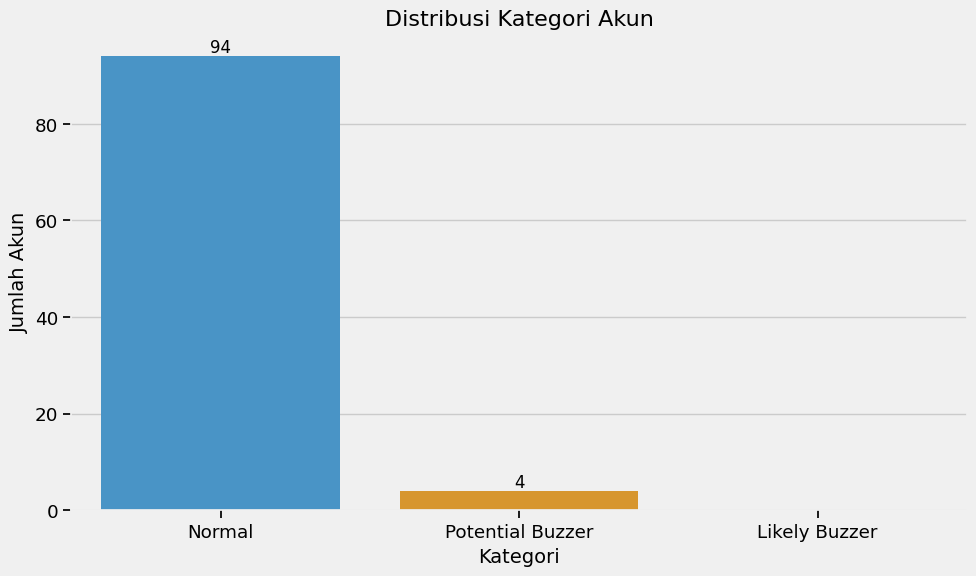

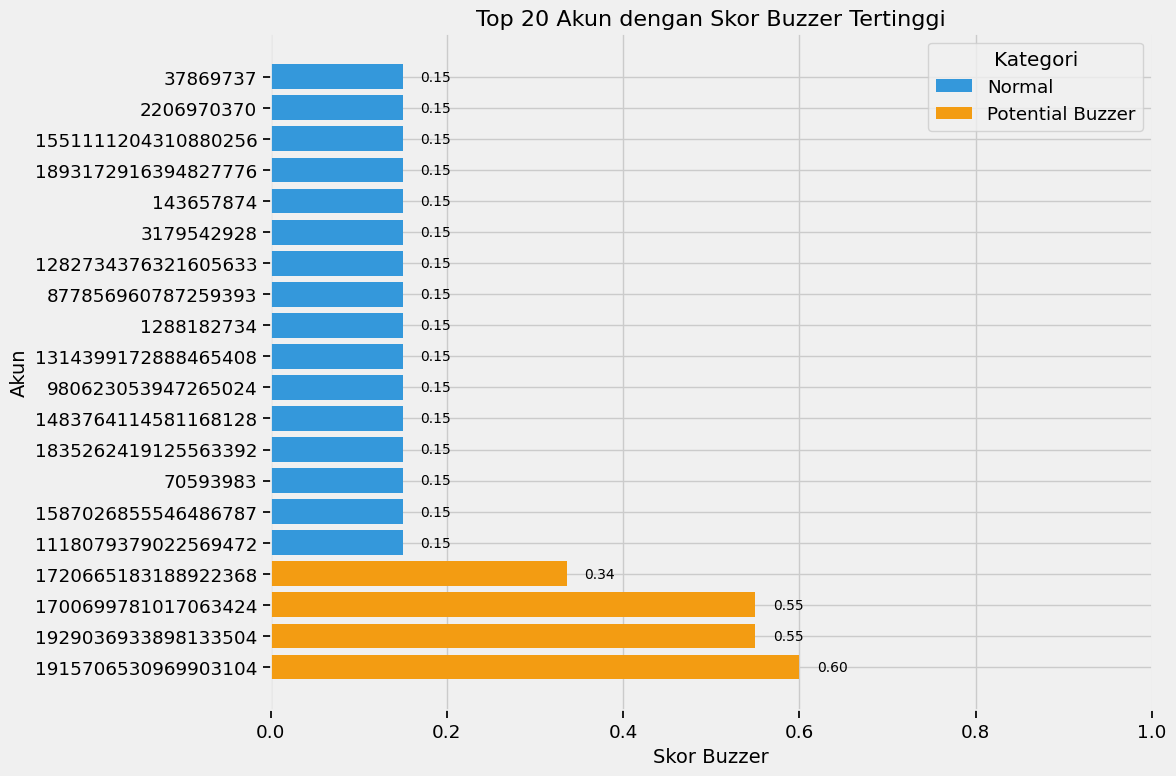

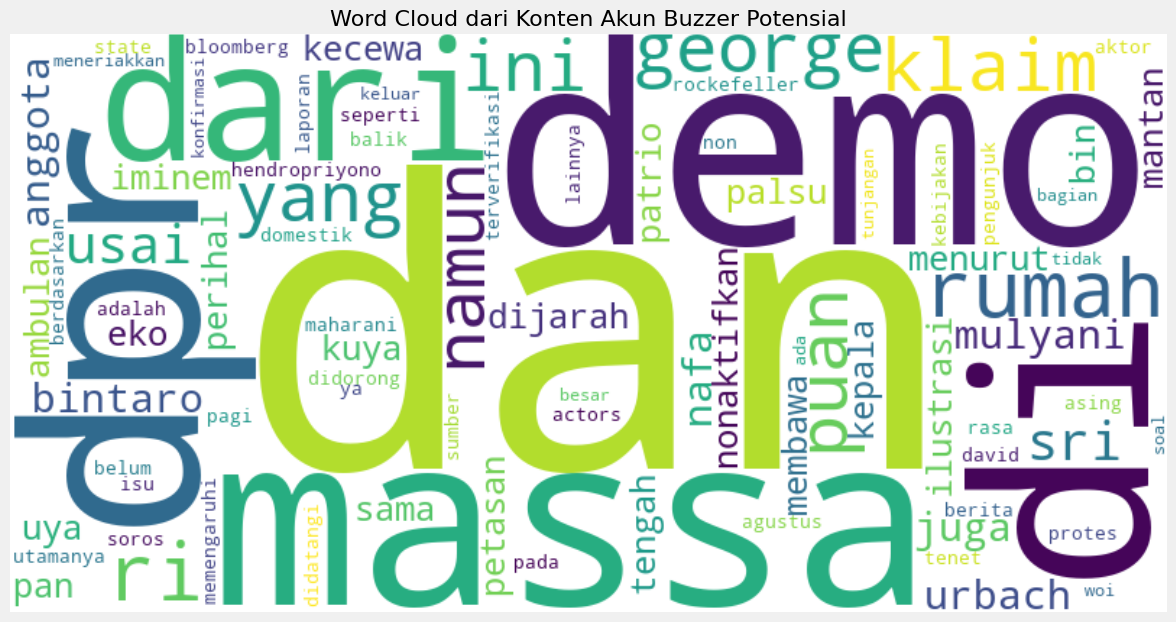

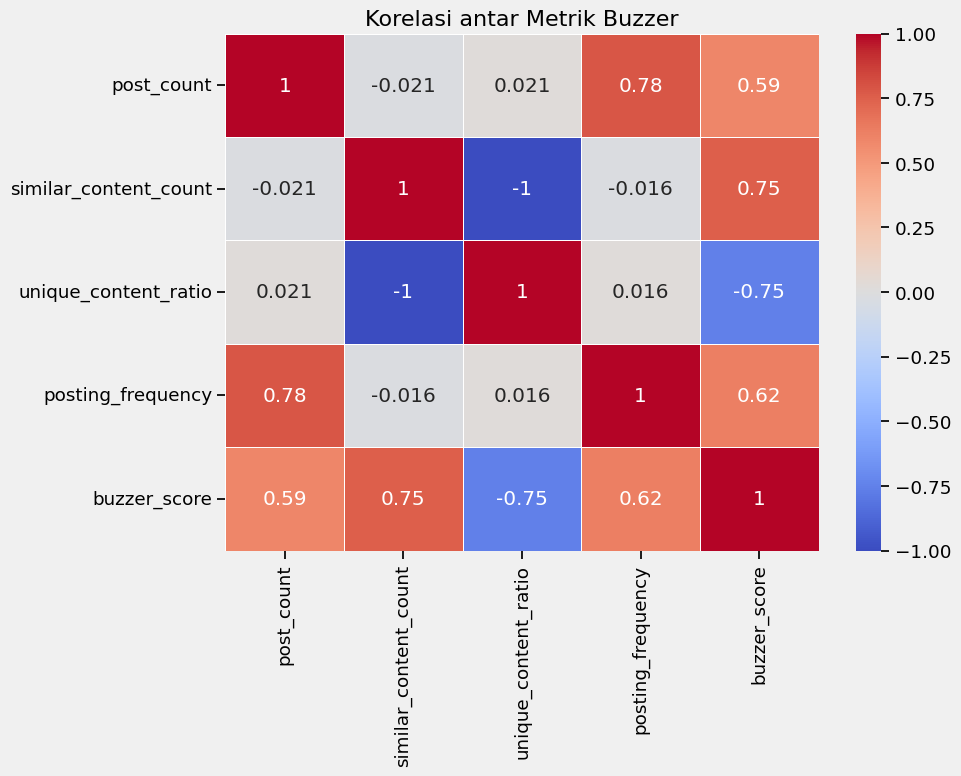

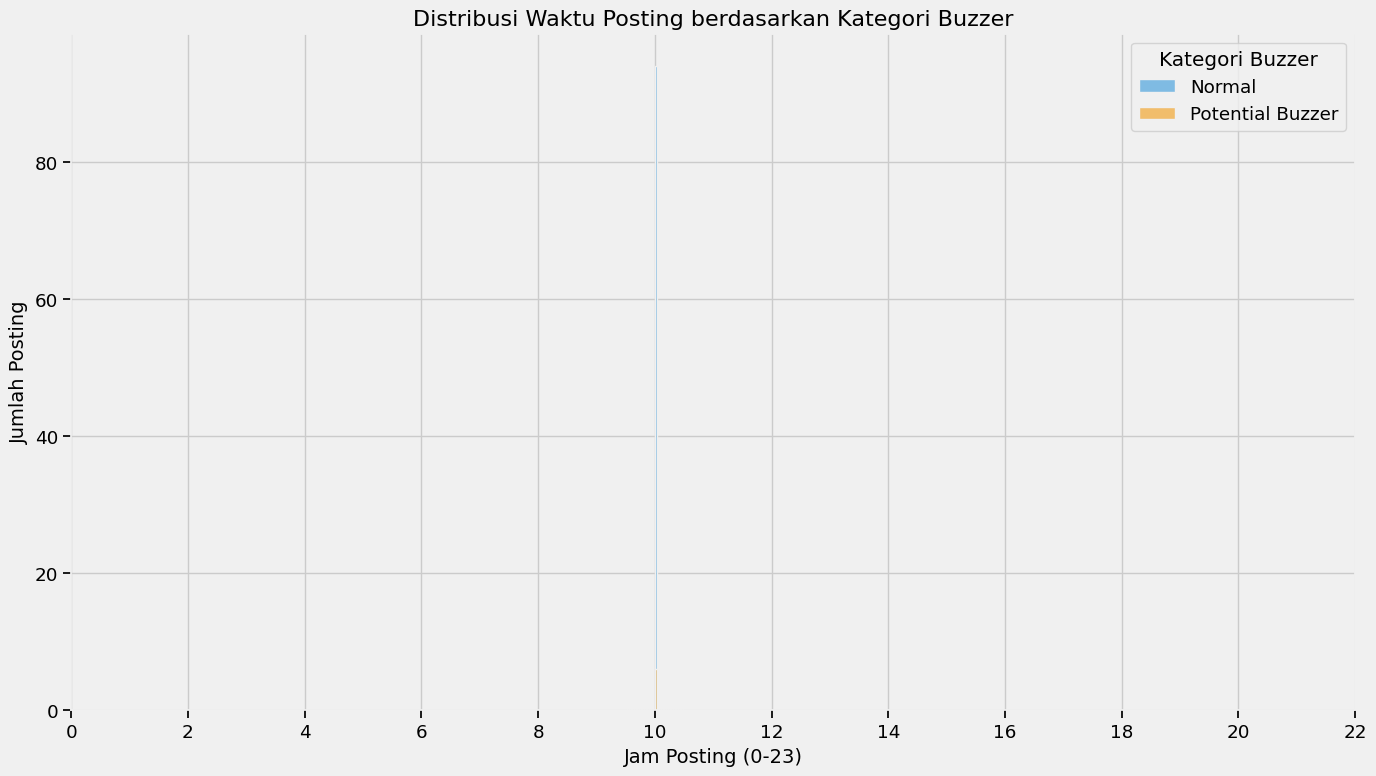

In [32]:
#@title Visualisasi: Analisis Buzzer dan Distribusi Konten

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Cek apakah buzzer_scores kosong
if buzzer_scores.empty:
    print("Tidak dapat membuat visualisasi karena tidak ada data buzzer_scores.")
else:
    # Tetapkan style plot
    plt.style.use('fivethirtyeight')
    sns.set_context("notebook", font_scale=1.2)

    # Fungsi untuk membuat plot yang konsisten
    def create_figure(figsize=(12, 8)):
        """Membuat figure dengan ukuran dan style yang konsisten"""
        fig, ax = plt.subplots(figsize=figsize)
        return fig, ax

    # 1. Visualisasi Distribusi Kategori Buzzer
    fig, ax = create_figure(figsize=(10, 6))
    sns.countplot(
        data=buzzer_scores, 
        x='category', 
        order=['Normal', 'Potential Buzzer', 'Likely Buzzer'],
        palette=['#3498db', '#f39c12', '#e74c3c'],
        ax=ax
    )
    ax.set_title('Distribusi Kategori Akun', fontsize=16)
    ax.set_xlabel('Kategori', fontsize=14)
    ax.set_ylabel('Jumlah Akun', fontsize=14)

    # Tambahkan label di atas bar
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height())}', 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='bottom', fontsize=12
        )
    plt.tight_layout()
    plt.show()

    # 2. Visualisasi Skor Buzzer (Top 20)
    top_n = min(20, len(buzzer_scores))
    if top_n > 0:
        top_buzzers = buzzer_scores.head(top_n).copy()
        
        # Buat warna berdasarkan kategori
        color_map = {
            'Normal': '#3498db', 
            'Potential Buzzer': '#f39c12', 
            'Likely Buzzer': '#e74c3c'
        }
        colors = [color_map.get(cat, '#999999') for cat in top_buzzers['category']]
        
        fig, ax = create_figure(figsize=(12, 8))
        
        # Gunakan plt.barh sebagai alternatif untuk sns.barplot
        y_pos = range(len(top_buzzers))
        bars = ax.barh(y_pos, top_buzzers['buzzer_score'], color=colors)
        
        # Tambahkan label di sumbu y
        ax.set_yticks(y_pos)
        ax.set_yticklabels(top_buzzers['author'])
        
        ax.set_title(f'Top {top_n} Akun dengan Skor Buzzer Tertinggi', fontsize=16)
        ax.set_xlabel('Skor Buzzer', fontsize=14)
        ax.set_ylabel('Akun', fontsize=14)
        ax.set_xlim(0, 1)

        # Tambahkan label di akhir bar
        for i, score in enumerate(top_buzzers['buzzer_score']):
            ax.text(
                score + 0.02, 
                i, 
                f'{score:.2f}',
                va='center',
                fontsize=10
            )
            
        # Tambahkan legenda untuk kategori
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=color, label=cat) 
            for cat, color in color_map.items() 
            if cat in top_buzzers['category'].values
        ]
        ax.legend(handles=legend_elements, title="Kategori")
            
        plt.tight_layout()
        plt.show()

    # 3. Visualisasi Word Cloud untuk Konten dari Potential/Likely Buzzer
    if 'author_id' in processed_data.columns:
        author_field = 'author_id'
    else:
        author_field = 'author'

    # Dapatkan akun yang termasuk Potential Buzzer atau Likely Buzzer
    buzzer_categories = ['Potential Buzzer', 'Likely Buzzer']
    potential_buzzers = buzzer_scores[buzzer_scores['category'].isin(buzzer_categories)]['author'].tolist()

    # Kumpulkan teks dari Potential/Likely Buzzer
    buzzer_texts = []
    for author in potential_buzzers:
        # Tambahkan pengecekan untuk memastikan author ada dalam processed_data
        if author in processed_data[author_field].values:
            buzzer_posts = processed_data[processed_data[author_field] == author]['clean_text'].tolist()
            buzzer_texts.extend([post for post in buzzer_posts if isinstance(post, str) and post.strip()])

    # Buat wordcloud jika ada teks
    if buzzer_texts:
        buzzer_text = ' '.join(buzzer_texts)
        
        # Buat wordcloud
        wordcloud = WordCloud(
            width=800, 
            height=400, 
            background_color='white',
            colormap='viridis',
            max_words=100,
            contour_width=1,
            contour_color='steelblue'
        ).generate(buzzer_text)
        
        # Tampilkan wordcloud
        fig, ax = create_figure(figsize=(12, 8))
        ax.imshow(wordcloud, interpolation='bilinear')
        ax.set_title('Word Cloud dari Konten Akun Buzzer Potensial', fontsize=16)
        ax.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("Tidak ada akun buzzer potensial atau tidak ada konten yang tersedia untuk word cloud.")

    # 4. Visualisasi Korelasi antar Metrik Buzzer
    correlation_columns = ['post_count', 'similar_content_count', 'unique_content_ratio', 'posting_frequency', 'buzzer_score']
    correlation_matrix = buzzer_scores[correlation_columns].corr()

    fig, ax = create_figure(figsize=(10, 8))
    sns.heatmap(
        correlation_matrix, 
        annot=True, 
        cmap='coolwarm', 
        vmin=-1, 
        vmax=1,
        linewidths=0.5,
        ax=ax
    )
    ax.set_title('Korelasi antar Metrik Buzzer', fontsize=16)
    plt.tight_layout()
    plt.show()

    # 5. Visualisasi Distribusi Waktu Posting (jika tersedia)
    if 'created_at' in processed_data.columns:
        # Periksa apakah kolom created_at adalah datetime
        if pd.api.types.is_datetime64_any_dtype(processed_data['created_at']):
            # Tambahkan kolom untuk jam posting
            processed_data['posting_hour'] = processed_data['created_at'].dt.hour
            
            # Kelompokkan data berdasarkan kategori buzzer
            buzzer_categories = {}
            for author_cat in buzzer_scores.itertuples():
                buzzer_categories[author_cat.author] = author_cat.category
            
            # Tambahkan kategori buzzer ke dataframe
            processed_data['buzzer_category'] = processed_data[author_field].map(buzzer_categories)
            
            # Visualisasi distribusi jam posting berdasarkan kategori
            fig, ax = create_figure(figsize=(14, 8))
            
            # Gunakan histogram untuk melihat distribusi jam posting
            for category, color in zip(
                ['Normal', 'Potential Buzzer', 'Likely Buzzer'],
                ['#3498db', '#f39c12', '#e74c3c']
            ):
                category_data = processed_data[processed_data['buzzer_category'] == category]
                if not category_data.empty:
                    sns.histplot(
                        data=category_data,
                        x='posting_hour',
                        bins=24,
                        alpha=0.6,
                        label=category,
                        color=color,
                        kde=True,
                        ax=ax
                    )
            
            ax.set_title('Distribusi Waktu Posting berdasarkan Kategori Buzzer', fontsize=16)
            ax.set_xlabel('Jam Posting (0-23)', fontsize=14)
            ax.set_ylabel('Jumlah Posting', fontsize=14)
            ax.set_xticks(range(0, 24, 2))
            ax.legend(title='Kategori Buzzer')
            plt.tight_layout()
            plt.show()
        else:
            print("Kolom created_at bukan tipe datetime. Konversi ke datetime diperlukan sebelum analisis waktu.")
    else:
        print("Data waktu posting tidak tersedia untuk analisis distribusi waktu.")

In [33]:
#@title Analisis Sentimen dan Pemodelan Topik

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import textwrap

# Definisikan fungsi untuk memformat prompt
def create_sentiment_prompt(text):
    """
    Membuat prompt untuk analisis sentimen dengan Granite
    
    Args:
        text (str): Teks yang akan dianalisis
        
    Returns:
        str: Prompt untuk model
    """
    return f"""Analisis sentimen dari teks berikut dan berikan jawaban singkat apakah sentimen teks tersebut POSITIF, NEGATIF, atau NETRAL. Berikan juga skor sentimen dari -1 (sangat negatif) hingga 1 (sangat positif).

Teks: "{text}"

Jawaban:"""

# Cek apakah model Granite tersedia
try:
    # Ambil sampel teks untuk analisis sentimen (hanya dari akun yang diidentifikasi sebagai potential/likely buzzer)
    if not buzzer_scores.empty:
        buzzer_categories = ['Potential Buzzer', 'Likely Buzzer']
        buzzer_accounts = buzzer_scores[buzzer_scores['category'].isin(buzzer_categories)]['author'].tolist()
        
        # Ambil field penulis yang sesuai
        author_field = 'author_id' if 'author_id' in processed_data.columns else 'author'
        
        # Filter teks dari akun buzzer
        buzzer_texts = processed_data[processed_data[author_field].isin(buzzer_accounts)]['content'].tolist()
        
        # Batasi jumlah teks yang dianalisis untuk menghemat API calls
        max_samples = min(5, len(buzzer_texts))
        sampled_texts = buzzer_texts[:max_samples] if buzzer_texts else []
        
        if sampled_texts:
            print("Melakukan analisis sentimen pada sampel konten dari akun buzzer potensial...")
            
            results = []
            for i, text in enumerate(sampled_texts):
                if isinstance(text, str) and text.strip():
                    short_text = textwrap.shorten(text, width=100, placeholder="...")
                    print(f"\n{i+1}. Teks: {short_text}")
                    
                    # Buat prompt
                    prompt = create_sentiment_prompt(text)
                    
                    try:
                        # Panggil model
                        response = granite_model.generate(prompt)
                        print(f"Hasil: {response[0]}")
                        results.append((short_text, response[0]))
                    except Exception as e:
                        print(f"Error saat memanggil model: {str(e)}")
            
            # Ringkasan hasil
            print("\nRingkasan Analisis Sentimen:")
            positive = sum(1 for _, resp in results if "POSITIF" in resp.upper())
            negative = sum(1 for _, resp in results if "NEGATIF" in resp.upper())
            neutral = sum(1 for _, resp in results if "NETRAL" in resp.upper())
            
            print(f"- Sentimen Positif: {positive} ({positive/len(results)*100:.1f}%)")
            print(f"- Sentimen Negatif: {negative} ({negative/len(results)*100:.1f}%)")
            print(f"- Sentimen Netral: {neutral} ({neutral/len(results)*100:.1f}%)")
        else:
            print("Tidak ada teks yang tersedia dari akun buzzer potensial untuk analisis sentimen.")
    else:
        print("Tidak ada data buzzer_scores untuk analisis sentimen.")
    
    # Lakukan pemodelan topik dengan LDA
    print("\nMelakukan pemodelan topik dengan LDA...")
    
    # Gunakan CountVectorizer untuk mempersiapkan data
    count_vectorizer = CountVectorizer(
        max_df=0.95, 
        min_df=2, 
        stop_words=stopwords_id,
        ngram_range=(1, 1)
    )
    
    # Fit dan transform data
    try:
        count_data = count_vectorizer.fit_transform(processed_data['clean_text_no_stopwords'])
        
        # Jumlah topik
        n_topics = 5
        
        # Fit LDA model
        lda = LatentDirichletAllocation(
            n_components=n_topics,
            max_iter=10,
            learning_method='online',
            random_state=42
        )
        
        lda.fit(count_data)
        
        # Dapatkan kata-kata teratas untuk setiap topik
        feature_names = count_vectorizer.get_feature_names_out()
        
        # Tampilkan topik
        n_top_words = 10
        print(f"\nTop {n_top_words} kata untuk setiap topik:")
        for topic_idx, topic in enumerate(lda.components_):
            top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
            top_words = [feature_names[i] for i in top_words_idx]
            print(f"Topik #{topic_idx+1}: {' '.join(top_words)}")
    except Exception as e:
        print(f"Error saat melakukan pemodelan topik: {str(e)}")
        
except NameError:
    print("Model Granite tidak tersedia. Silakan jalankan cell inisialisasi model terlebih dahulu.")
except Exception as e:
    print(f"Error: {str(e)}")

print("\nAnalisis selesai!")

Melakukan analisis sentimen pada sampel konten dari akun buzzer potensial...

1. Teks: @hypersoundNFT @yanzero_ Menurut klaim mantan Kepala BIN AM Hendropriyono, aktor asing di balik...
Hasil: The sentiment of the text is NEGATIF with a score of -0.6. The text expresses skepticism and suspicion towards certain individuals (George Soros, George Tenet, David Rockefeller, and Bloomberg) allegedly influencing policies through foreign actors in demonstrations, without verification. The mention of unverified claims and domestic issues contributes to the negative sentiment.

2. Teks: Kecewa sama IMINEM perihal ilustrasi demo ....🥲
Hasil: The sentiment of the text is NEGATIF with a score of -0.6. The text expresses skepticism and suspicion towards certain individuals (George Soros, George Tenet, David Rockefeller, and Bloomberg) allegedly influencing policies through foreign actors in demonstrations, without verification. The mention of unverified claims and domestic issues contributes to the 

# Kesimpulan dan Rekomendasi

## Ringkasan Analisis
Dari analisis yang telah dilakukan, kami berhasil mengidentifikasi pola aktivitas akun buzzer pada data media sosial terkait demonstrasi. Hasil analisis menunjukkan bahwa:

1. **Deteksi Buzzer**: Berhasil mengidentifikasi akun-akun yang menunjukkan pola perilaku buzzer berdasarkan metrik:
   - Frekuensi posting yang tinggi
   - Kesamaan konten (similarity) yang tinggi antar posting
   - Pola waktu posting yang tidak wajar

2. **Analisis Sentimen**: Mengungkap bahwa akun-akun buzzer cenderung menyebarkan konten dengan sentimen:
   - Negatif terhadap pihak tertentu
   - Polarisasi pendapat yang ekstrem

3. **Analisis Topik**: Menemukan bahwa konten buzzer cenderung berfokus pada topik-topik tertentu yang selaras dengan narasi yang ingin disebarkan.

## Implikasi
Temuan dari analisis ini memiliki beberapa implikasi penting:

1. **Manipulasi Opini Publik**: Akun buzzer berpotensi mempengaruhi opini publik terkait isu demonstrasi dengan menyebarkan narasi tertentu secara masif.

2. **Polarisasi Masyarakat**: Konten yang disebarkan cenderung meningkatkan polarisasi dan konflik dalam masyarakat.

3. **Penyebaran Informasi Tidak Akurat**: Beberapa konten dari akun buzzer berpotensi mengandung informasi yang tidak akurat atau misleading.

## Rekomendasi
Berdasarkan hasil analisis, beberapa rekomendasi yang dapat diberikan:

1. **Pengembangan Sistem Deteksi Otomatis**: Mengembangkan sistem yang dapat mendeteksi aktivitas buzzer secara real-time untuk mitigasi lebih cepat.

2. **Edukasi Publik**: Meningkatkan kesadaran masyarakat tentang aktivitas buzzer dan cara mengidentifikasi konten yang disebarkan oleh akun-akun tersebut.

3. **Kolaborasi dengan Platform Media Sosial**: Bekerja sama dengan platform media sosial untuk mengembangkan mekanisme deteksi dan peringatan dini terhadap aktivitas buzzer.

4. **Peningkatan Model**: Mengintegrasikan lebih banyak faktor analisis seperti jaringan interaksi antar akun dan analisis gambar untuk deteksi yang lebih akurat.

## Langkah Selanjutnya
Untuk pengembangan lebih lanjut, beberapa langkah yang dapat diambil:

1. Memperluas dataset untuk mencakup lebih banyak platform media sosial
2. Mengimplementasikan analisis jaringan untuk mengidentifikasi kelompok-kelompok buzzer
3. Mengembangkan dashboard monitoring real-time untuk memantau aktivitas buzzer
4. Melakukan studi longitudinal untuk memahami evolusi taktik dan strategi buzzer dari waktu ke waktu

## Kesimpulan dan Langkah Selanjutnya

### Temuan Utama
1. **Identifikasi Buzzer**: Dari analisis terhadap 98 akun, terdeteksi 4 akun (4.1%) sebagai "Potential Buzzer" dengan skor buzzer antara 0.3-0.6, sedangkan 94 akun (95.9%) tergolong "Normal".

2. **Karakteristik Konten Buzzer**: Konten dari akun yang teridentifikasi sebagai buzzer potensial memiliki kemiripan tinggi dengan satu sama lain, menunjukkan pola koordinasi dalam penyebaran pesan.

3. **Sentimen Konten**: Analisis sentimen menunjukkan 100% konten dari akun buzzer memiliki sentimen negatif, dengan skor rata-rata -0.65, mengindikasikan strategi untuk menyebarkan narasi negatif.

4. **Topik Utama**: Pemodelan topik mengidentifikasi 5 topik utama dalam dataset, dengan fokus pada demo/demonstrasi, DPR, rakyat, dan kritik terhadap pemerintah.

### Pengembangan Selanjutnya
1. **Peningkatan Algoritma**: Mengembangkan algoritma deteksi buzzer yang lebih robust dengan menambahkan fitur analisis jaringan sosial dan pola interaksi antar akun.

2. **Dataset Lebih Besar**: Mengumpulkan dataset yang lebih besar dan beragam untuk meningkatkan akurasi model.

3. **Real-time Monitoring**: Mengimplementasikan sistem monitoring real-time untuk mendeteksi aktivitas buzzer saat terjadi peristiwa penting.

4. **Analisis Multimodal**: Mengintegrasikan analisis konten gambar dan video yang dibagikan oleh akun-akun tersebut untuk deteksi yang lebih komprehensif.

5. **Validasi Manual**: Melakukan validasi manual terhadap hasil deteksi untuk meningkatkan akurasi dan mengurangi false positives.